In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.patches import Rectangle

In [ ]:
# INVIVO HV01

plane = 'z'
z_start = 10
full_slice = False
abs = False
meas = 'w'
t_index = 3

vmin = -0.3
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40
x_start = 79#78
y_start = 68#70
line_thickness = 3 # or whatever

h5_filename = '../data/invivo/HV01.h5'
output_png = f"2D_plots/HV01_invivo_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

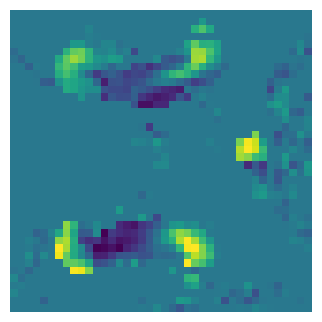

In [7]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [8]:
# INVIVO HV01 - PINN

plane = 'z'
z_start = 10*2
full_slice = False
abs = False
meas = 'w'
t_index = 3*2

vmin = -0.3
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40*2
x_start = 79*2#78
y_start = 68*2#70
line_thickness = 3 # or whatever

h5_filename = '../models/251221_WIRE_MOMENTUM_INVIVO/251221_WIRE_MOMENTUM_HV01_INVIVO_PINN/251209_WIRE_MOMENTUM_SV_NewMask_HV01_invivo_20260108-2105/SR_final.h5'
output_png = f"2D_plots/HV01_invivo_css1_PINN_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

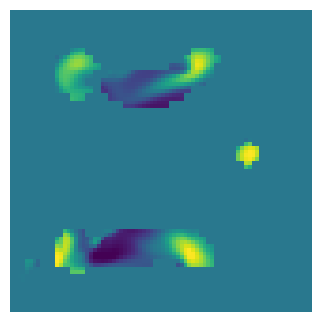

In [9]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [10]:
# INVIVO HV01 - INR

plane = 'z'
z_start = 10*2
full_slice = False
abs = False
meas = 'w'
t_index = 3*2

vmin = -0.3
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40*2
x_start = 79*2#78
y_start = 68*2#70
line_thickness = 3 # or whatever

h5_filename = '../models/251216_WIRE_DD_INVIVO/251216_WIRE_SV_NewMask_HV01_invivo_20260108-2056/SR_final.h5'
output_png = f"2D_plots/HV01_invivo_css1_INR_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

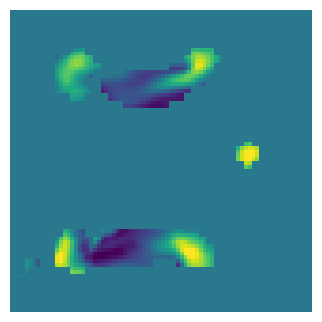

In [11]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

### ICAD21

In [ ]:
# INVIVO ICAD21 - INR

plane = 'z'
z_start = 22*2
full_slice = False
abs = False
meas = 'u'
t_index = 3*2

vmin = -0.5
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40*2
dim_x = 28*2 # 56
dim_y = 16*2 # 30
x_start = 53*2#78
y_start = 73*2#70
line_thickness = 3 # or whatever

h5_filename = '../models/251216_WIRE_DD_INVIVO/251216_WIRE_SV_NewMask_ICAD21_invivo_20260108-2122/SR_final.h5'
output_png = f"2D_plots/ICAD21_invivo_css1_INR_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

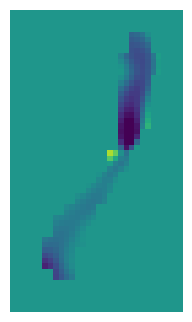

In [16]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim_x, 
                        y_start:y_start+dim_y, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [18]:
# INVIVO ICAD21 - PINN

plane = 'z'
z_start = 22*2
full_slice = False
abs = False
meas = 'u'
t_index = 3*2

vmin = -0.5
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40*2
dim_x = 28*2 # 56
dim_y = 16*2 # 30
x_start = 53*2#78
y_start = 73*2#70
line_thickness = 3 # or whatever

h5_filename = '../models/251221_WIRE_MOMENTUM_INVIVO/251221_WIRE_MOMENTUM_ICAD21_INVIVO_PINN/251209_WIRE_MOMENTUM_SV_NewMask_ICAD21_invivo_20260108-2110/SR_final.h5'
output_png = f"2D_plots/ICAD21_invivo_css1_PINN_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

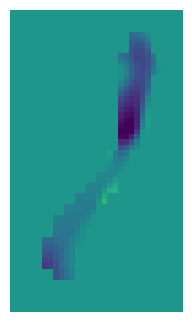

In [19]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim_x, 
                        y_start:y_start+dim_y, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [22]:
# INVIVO ICAD21

plane = 'z'
z_start = 22
full_slice = False
abs = False
meas = 'u'
t_index = 3

vmin = -0.5
vmax = 0.45
cmap = 'viridis'

plot_red_square = False
dim = 40
dim_x = 28 # 56
dim_y = 16 # 30
x_start = 53#78
y_start = 73#70
line_thickness = 3 # or whatever

h5_filename = '../data/invivo/ICAD21.h5'
output_png = f"2D_plots/ICAD21_invivo_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

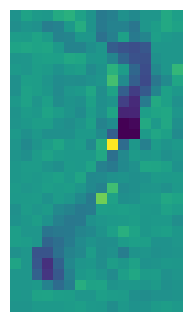

In [23]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim_x, 
                        y_start:y_start+dim_y, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

## Aliasing Fig - HV01

In [48]:
# HV01 HR

plane = 'z'
z_start = 14
full_slice = False
abs = False
meas = 'w'
t_index = 6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 42#78
y_start = 22#70
line_thickness = 3 # or whatever

h5_filename = '../data/healthy/HV01_05mm3_20ms.h5'
output_png = f"2D_plots/HR_HV01_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

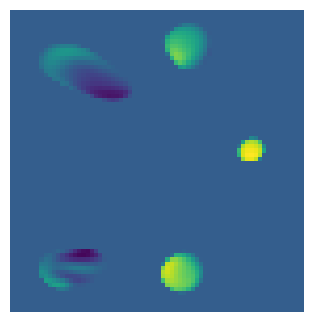

In [49]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [50]:
# HV01 SR - SV05

plane = 'z'
z_start = 14
full_slice = False
abs = False
meas = 'w'
t_index = 6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 42#78
y_start = 22#70
line_thickness = 3 # or whatever

h5_filename = '../models/251230_WIRE_DD_PINN_RESULTS/251216_WIRE_HV01_VENC/251216_WIRE_MOMENTUM_SV_NewMask_HV01_sv05_omega20_sigma20_20260108-1905/SR_final.h5'
output_png = f"2D_plots/SR_SV05_HV01_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

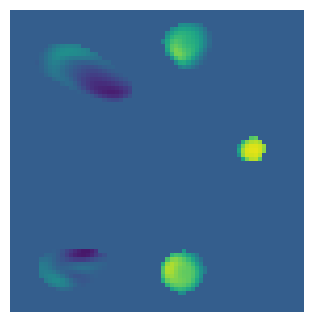

In [51]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [52]:
# HV01 LR

plane = 'z'
z_start = 7# 14
full_slice = False
abs = False
meas = 'w'
t_index = 3#6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 36#72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 21#42#78
y_start = 11#22#70
line_thickness = 3 # or whatever

h5_filename = '../data/healthy/HV01_05mm3_20ms_LR_sv05_tSNR10_newMask.h5'
output_png = f"2D_plots/LR_HV01_SV05_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

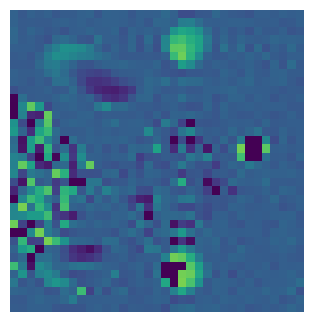

In [53]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [54]:
# HV01 LR - SV 03

plane = 'z'
z_start = 7# 14
full_slice = False
abs = False
meas = 'w'
t_index = 3#6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 36#72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 21#42#78
y_start = 11#22#70
line_thickness = 3 # or whatever

h5_filename = '../data/healthy/HV01_05mm3_20ms_LR_sv03_tSNR10_newMask.h5'
output_png = f"2D_plots/LR_HV01_SV03_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

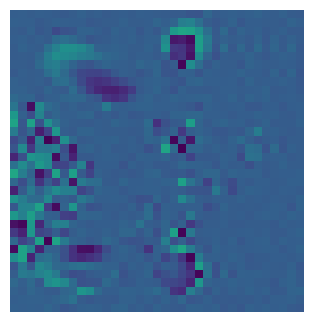

In [55]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [57]:
# HV01 SR - SV03

plane = 'z'
z_start = 14
full_slice = False
abs = False
meas = 'w'
t_index = 6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 42#78
y_start = 22#70
line_thickness = 3 # or whatever

h5_filename = '../models/251216_WIRE_HV01_VENC/251216_WIRE_MOMENTUM_SV_NewMask_HV01_sv03_omega20_sigma20_20260113-1500/SR_final.h5'
output_png = f"2D_plots/SR_SV03_HV01_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

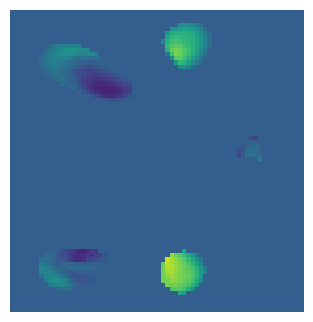

In [58]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [60]:
# HV01 SR - SV03

plane = 'z'
z_start = 14
full_slice = False
abs = False
meas = 'w'
t_index = 6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 42#78
y_start = 22#70
line_thickness = 3 # or whatever

h5_filename = '../models/251216_WIRE_HV01_VENC/251216_WIRE_MOMENTUM_SV_NewMask_HV01_sv02_omega20_sigma20_20260113-1457/SR_final.h5'
output_png = f"2D_plots/SR_SV02_HV01_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

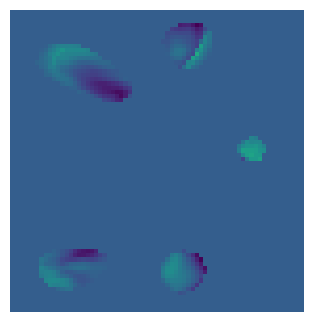

In [61]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()

In [62]:
# HV01 LR - SV 03

plane = 'z'
z_start = 7# 14
full_slice = False
abs = False
meas = 'w'
t_index = 3#6

vmin = -0.3
vmax = 0.7
cmap = 'viridis'

plot_red_square = False
dim = 36#72
#dim_x = 28 # 56
#dim_y = 16 # 30
x_start = 21#42#78
y_start = 11#22#70
line_thickness = 3 # or whatever

h5_filename = '../data/healthy/HV01_05mm3_20ms_LR_sv02_tSNR10_newMask.h5'
output_png = f"2D_plots/LR_HV01_SV02_healthy_css1_z{z_start}_vmin{vmin}_vmax{vmax}_xstart{x_start}_ystart{y_start}.png"

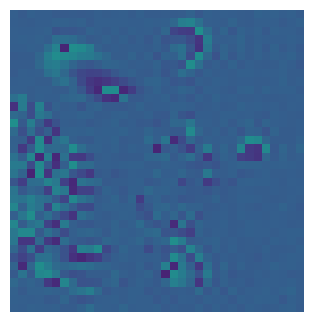

In [63]:
# Open the HDF5 file and read data
with h5py.File(h5_filename, 'r') as f:
    if t_index:
        data_3d = f[meas][t_index]  # shape should be [nx, ny, nz]
    else:
        data_3d = f[meas][0]  # shape should be [nx, ny, nz]


if full_slice:   
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        :, 
                        :]
    if plane == 'y':
        slice_2d = data_3d[:, 
                        y_start, 
                        :]
    if plane == 'z':
        slice_2d = data_3d[:, 
                        :, 
                        z_start]
else:
    # Extract the slice: data_3d[x_idx, y_start : y_start+dim_y, z_start : z_start+dim_z]
    # Note: confirm your data shape/axes if needed
    if plane == 'x':
        slice_2d = data_3d[x_start, 
                        y_start:y_start+dim, 
                        z_start:z_start+dim]
    if plane == 'y':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start, 
                        z_start:z_start+dim]
    if plane == 'z':
        slice_2d = data_3d[x_start:x_start+dim, 
                        y_start:y_start+dim, 
                        z_start]

# Plot the slice
if full_slice:

    H, W = slice_2d.shape
    scale = 4  # make it bigger but still pixel-aligned
    dpi = 100
    fig_w = (W*scale) / dpi
    fig_h = (H*scale) / dpi

    print(fig_w, fig_h)
    fig_w = 13
    fig_h = 11

    plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
else:
    plt.figure(figsize=(4, 4), dpi=100)  # figsize can be adapted

if abs:
    slice_2d = np.abs(slice_2d)

plt.imshow(slice_2d, 
            cmap=cmap, 
            origin='lower',  # or 'upper' depending on your coordinate system
            vmin=vmin, vmax=vmax,
            interpolation='nearest')


if full_slice and plot_red_square:
    # Map (row, col) depending on the slicing plane
    if plane == 'z':        # slice shape: [nx, ny]
        r0, c0 = x_start, y_start
    elif plane == 'y':      # slice shape: [nx, nz]
        r0, c0 = x_start, z_start
    elif plane == 'x':      # slice shape: [ny, nz]
        r0, c0 = y_start, z_start
    else:
        r0 = c0 = None  # safety

    if r0 is not None:
        ax = plt.gca()
        rect = Rectangle(
            (c0 - 0.5, r0 - 0.5),   # bottom-left at pixel edge
            dim,                    # width in pixels (columns)
            dim,                    # height in pixels (rows)
            fill=False,
            edgecolor='red',
            linewidth=line_thickness
        )
        ax.add_patch(rect)


# Remove all axes/borders/whitespace
plt.axis('off')

# Save the figure tightly around the image
plt.savefig(output_png, bbox_inches='tight', pad_inches=0)
plt.show()
plt.close()